<div align="center">

# 📊 Análisis Exploratorio de Datos (EDA)
### Sistema de Tutoría Inteligente Adaptativa para Comprensión Lectora mediante Deep Reinforcement Learning
**Grupo 2 · Maestría en Inteligencia Artificial · UNI**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yasminum/SistemaTutorInteligente/blob/eda/notebooks/01_EDA.ipynb)

</div>

---

**Objetivo.** Caracterizar las tres fuentes de datos del proyecto antes de cualquier inferencia: (1) el banco de ítems IRT, (2) la población de estudiantes simulados y (3) los registros de entrenamiento de la matriz de ablación B0–B5. El análisis cubre estructura, calidad, distribuciones, factibilidad del umbral de la hipótesis general (LG ≥ 0.50) e integridad de los registros.

**Reproducibilidad.** Las fuentes (1) y (2) se regeneran aquí con el mismo generador (`numpy.random.default_rng`) y el mismo orden de llamadas que `src/environment.py`, por lo que son idénticas a las usadas en el entrenamiento. La fuente (3) se lee de `data/results/ablation_summary_colab.json`, exportado de la corrida en Colab (GPU RTX A4000).

| # | Fuente | Naturaleza | Origen en el código | Volumen |
|---|---|---|---|---|
| 1 | Banco de ítems IRT-3PL | Sintética, paramétrica | `ReadingTutorEnv.__init__` | 30 textos × 10 ítems = 300 ítems por semilla |
| 2 | Estudiantes simulados | Sintética, θ ~ Beta(2,2) en 3 habilidades | `IRTStudent.__init__` | 1 estudiante por semilla (10) |
| 3 | Registros de entrenamiento | Salida experimental | `train.py` → `ablation_summary_colab.json` | 6 condiciones × 10 semillas × 5 000 episodios |

In [1]:
%pip install seaborn

In [2]:
# ============================================================
# 0. Configuración
# ============================================================
import os, json, hashlib, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

COLORS = {"B0": "#95a5a6", "B1": "#e67e22", "B2": "#3498db",
          "B3": "#2ecc71", "B4": "#9b59b6", "B5": "#e74c3c"}
SKILL_COLORS = ["#9b59b6", "#2ecc71", "#e74c3c"]
FIG_DIR, SAMPLE_DIR = "figures/eda", "data/sample"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(SAMPLE_DIR, exist_ok=True)

# Réplica de src/config.py (solo parámetros que afectan a los datos)
CONFIG = {"num_texts": 30, "num_items_per_text": 10, "num_skills": 3,
          "horizon": 50, "total_episodes": 5000}
SEEDS = list(range(10))
CONDS = ["B0", "B1", "B2", "B3", "B4", "B5"]
HG_THRESHOLD = 0.50   # Hipótesis general: LG_sim >= 0.50

def savefig(name):
    plt.savefig(f"{FIG_DIR}/{name}.png")
    plt.show()

def p_correct(theta, a, b, c=0.25, fatigue=0.0):
    """Modelo 3PL de IRTStudent.respond (incluye penalización por fatiga)."""
    return (c + (1 - c) / (1 + np.exp(-1.7 * a * (theta - b)))) * (1 - 0.1 * fatigue)

print("Entorno listo · numpy", np.__version__, "· pandas", pd.__version__)

Entorno listo · numpy 2.4.6 · pandas 3.0.2


---
## 1. Banco de ítems (IRT-3PL)

Cada ítem se describe con los parámetros del modelo logístico de 3 parámetros:

$$P(\text{correcta}\mid\theta) = c + \frac{1-c}{1+e^{-1.7\,a\,(\theta-b)}}$$

| Variable | Tipo | Generación en `environment.py` | Significado |
|---|---|---|---|
| `text_id` | entero 0–29 | índice del bucle | Texto al que pertenece el ítem (la acción del agente elige el texto) |
| `item_en_texto` | entero 0–9 | índice del bucle | Posición del ítem dentro del texto |
| `a_discriminacion` | real | U(0.8, 2.0) | Pendiente de la ICC |
| `b_dificultad` | real | N(0, 1) | Dificultad base (se desplaza ±0.5 según el nivel elegido por el agente) |
| `c_azar` | real | constante 0.25 | Probabilidad de acierto por azar (4 alternativas) |
| `habilidad` | entero 0–2 | U{0,1,2} | Habilidad lectora evaluada |

> **Nota metodológica.** En el pipeline computacional cada texto es un índice; el contenido textual (literatura peruana) no entra al modelo, solo sus parámetros psicométricos.

In [3]:
def build_item_bank(seed, cfg=CONFIG):
    """Réplica fiel de ReadingTutorEnv.__init__: mismo generador, mismo orden de llamadas."""
    rng = np.random.default_rng(seed)
    rows = []
    for t in range(cfg["num_texts"]):
        for j in range(cfg["num_items_per_text"]):
            a = rng.uniform(0.8, 2.0)
            b = rng.normal(0, 1)
            k = int(rng.integers(0, 3))
            rows.append({"seed": seed, "item_id": len(rows), "text_id": t, "item_en_texto": j,
                         "a_discriminacion": a, "b_dificultad": b, "c_azar": 0.25, "habilidad": k})
    return pd.DataFrame(rows)

items = pd.concat([build_item_bank(s) for s in SEEDS], ignore_index=True)
items0 = items[items.seed == 0].reset_index(drop=True)
items0.to_csv(f"{SAMPLE_DIR}/item_bank_seed0.csv", index=False)

print(f"Ítems por semilla: {len(items0)} | Semillas: {len(SEEDS)} | Filas totales: {len(items)}")
print("➡ Muestra de la data (semilla 0, primeras 10 filas) — guardada en data/sample/item_bank_seed0.csv")
items0.head(10)

Ítems por semilla: 300 | Semillas: 10 | Filas totales: 3000
➡ Muestra de la data (semilla 0, primeras 10 filas) — guardada en data/sample/item_bank_seed0.csv


,seed,item_id,text_id,item_en_texto,a_discriminacion,b_dificultad,c_azar,habilidad
0,0,0,0,0,1.5644,-0.1321,0.2500,0
1,0,1,0,1,0.8198,-0.5357,0.2500,0
2,0,2,0,2,1.8953,1.3040,0.2500,2
3,0,3,0,3,1.4523,-1.2654,0.2500,2
4,0,4,0,4,1.7790,0.0413,0.2500,1
5,0,5,0,5,0.8403,-1.2459,0.2500,2
6,0,6,0,6,1.0108,-0.5443,0.2500,0
7,0,7,0,7,1.1597,1.0425,0.2500,1
8,0,8,0,8,0.8340,1.3665,0.2500,0
9,0,9,0,9,1.5766,0.9035,0.2500,2


### 1.1 Calidad y estadística descriptiva

In [4]:
quality = pd.Series({
    "Valores nulos": int(items.isna().sum().sum()),
    "Duplicados (seed, text_id, item_en_texto)": int(items.duplicated(["seed", "text_id", "item_en_texto"]).sum()),
    "a fuera de [0.8, 2.0]": int((~items.a_discriminacion.between(0.8, 2.0)).sum()),
    "Ítems con b < 0 (%)": round(100 * (items.b_dificultad < 0).mean(), 1),
    "Ítems con b > 1 (%)": round(100 * (items.b_dificultad > 1).mean(), 1),
}, name="valor")
display(quality.to_frame())
items[["a_discriminacion", "b_dificultad", "c_azar"]].describe().T

,valor
Valores nulos,0.0000
"Duplicados (seed, text_id, item_en_texto)",0.0000
"a fuera de [0.8, 2.0]",0.0000
Ítems con b < 0 (%),51.8000
Ítems con b > 1 (%),14.6000


,count,mean,std,min,25%,50%,75%,max
a_discriminacion,"3,000.0000",1.4040,0.3463,0.8011,1.0995,1.4031,1.7113,1.9989
b_dificultad,"3,000.0000",-0.0308,0.9822,-3.8994,-0.6921,-0.0434,0.6405,3.3230
c_azar,"3,000.0000",0.2500,0.0000,0.2500,0.2500,0.2500,0.2500,0.2500


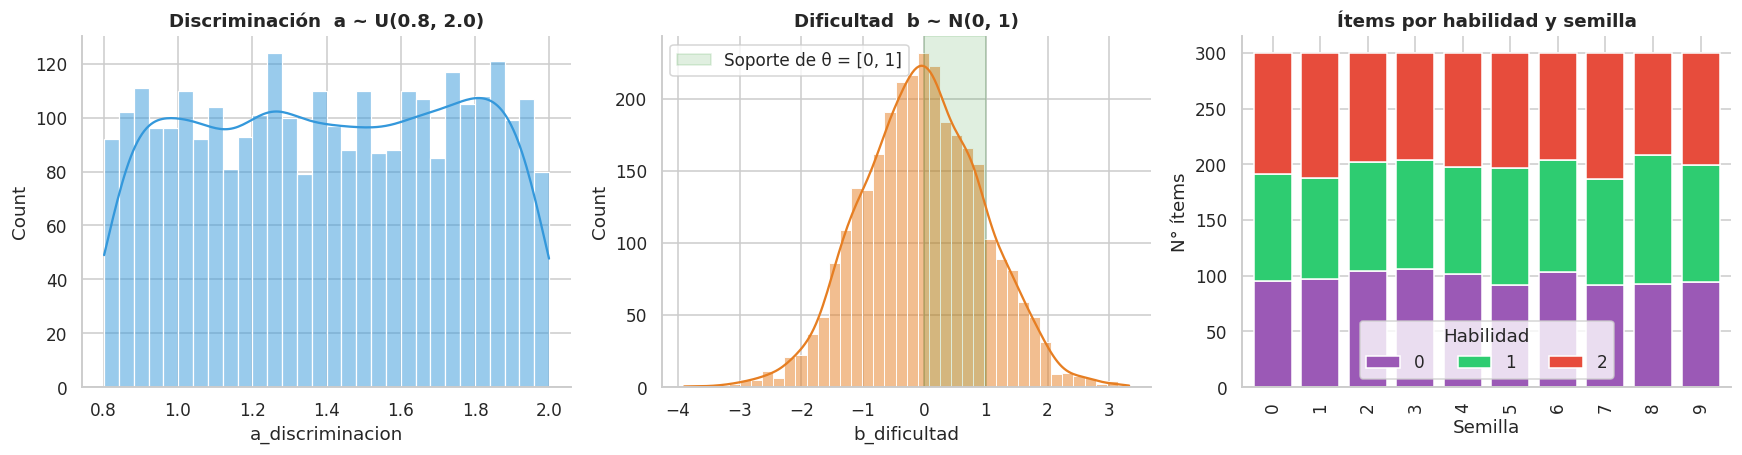

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
sns.histplot(items, x="a_discriminacion", bins=30, kde=True, ax=axes[0], color="#3498db")
axes[0].set_title("Discriminación  a ~ U(0.8, 2.0)")
sns.histplot(items, x="b_dificultad", bins=40, kde=True, ax=axes[1], color="#e67e22")
axes[1].axvspan(0, 1, color="green", alpha=0.12, label="Soporte de θ = [0, 1]")
axes[1].set_title("Dificultad  b ~ N(0, 1)")
axes[1].legend()
ct = items.groupby(["seed", "habilidad"]).size().unstack()
ct.plot(kind="bar", stacked=True, ax=axes[2], color=SKILL_COLORS, width=0.8)
axes[2].set(title="Ítems por habilidad y semilla", xlabel="Semilla", ylabel="N° ítems")
axes[2].legend(title="Habilidad", ncol=3, loc="lower center")
plt.tight_layout()
savefig("01_banco_items_distribuciones")

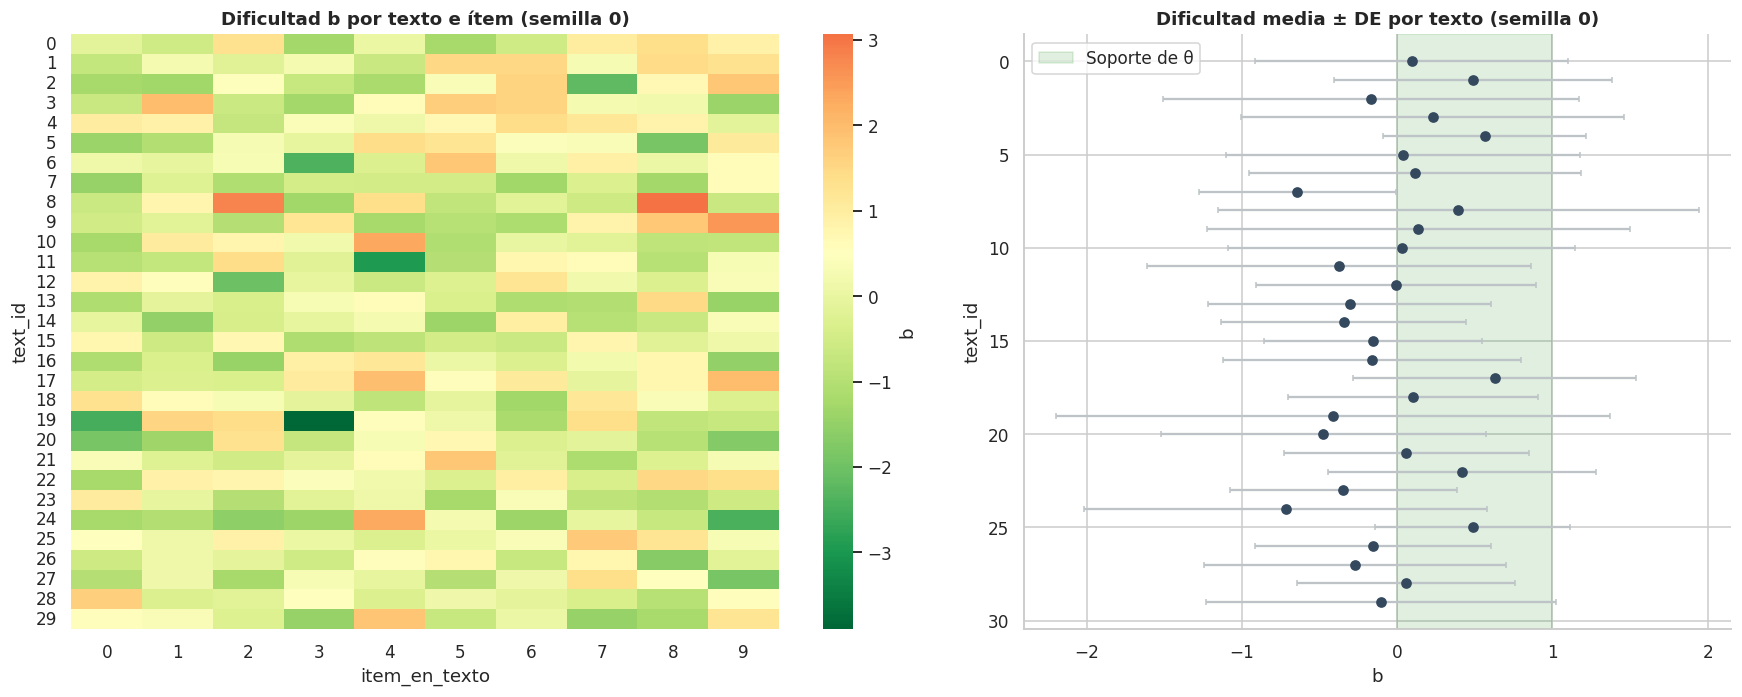

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), gridspec_kw={"width_ratios": [1.25, 1]})
piv = items0.pivot(index="text_id", columns="item_en_texto", values="b_dificultad")
sns.heatmap(piv, cmap="RdYlGn_r", center=0.5, ax=axes[0], cbar_kws={"label": "b"})
axes[0].set_title("Dificultad b por texto e ítem (semilla 0)")
txt = items0.groupby("text_id").agg(b_media=("b_dificultad", "mean"),
                                    b_sd=("b_dificultad", "std")).reset_index()
axes[1].errorbar(txt.b_media, txt.text_id, xerr=txt.b_sd, fmt="o", color="#34495e",
                 ecolor="#bdc3c7", capsize=2)
axes[1].axvspan(0, 1, color="green", alpha=0.12, label="Soporte de θ")
axes[1].invert_yaxis()
axes[1].set(title="Dificultad media ± DE por texto (semilla 0)", xlabel="b", ylabel="text_id")
axes[1].legend()
plt.tight_layout()
savefig("02_dificultad_por_texto")

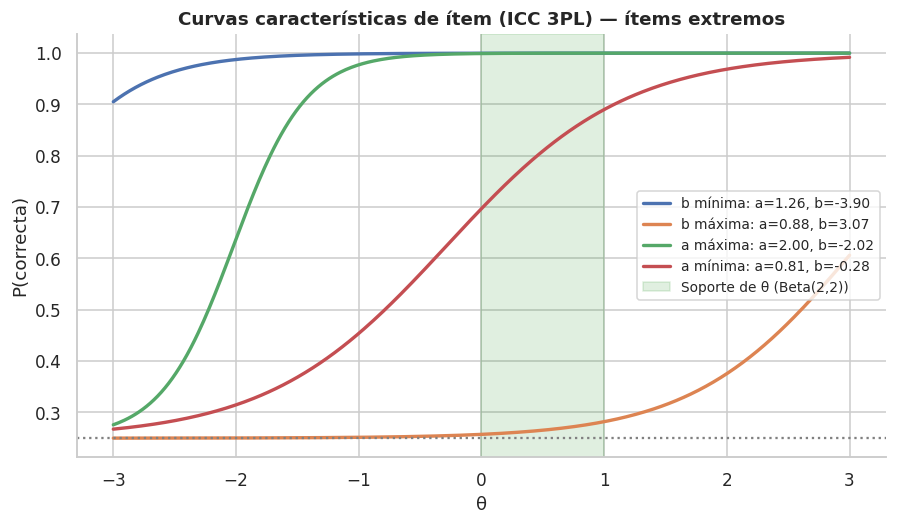

In [7]:
theta_grid = np.linspace(-3, 3, 400)
fig, ax = plt.subplots(figsize=(9.5, 5))
for label, idx in [("b mínima", items0.b_dificultad.idxmin()), ("b máxima", items0.b_dificultad.idxmax()),
                   ("a máxima", items0.a_discriminacion.idxmax()), ("a mínima", items0.a_discriminacion.idxmin())]:
    r = items0.loc[idx]
    ax.plot(theta_grid, p_correct(theta_grid, r.a_discriminacion, r.b_dificultad), lw=2.2,
            label=f"{label}: a={r.a_discriminacion:.2f}, b={r.b_dificultad:.2f}")
ax.axvspan(0, 1, color="green", alpha=0.12, label="Soporte de θ (Beta(2,2))")
ax.axhline(0.25, ls=":", c="gray")
ax.set(xlabel="θ", ylabel="P(correcta)", title="Curvas características de ítem (ICC 3PL) — ítems extremos")
ax.legend(fontsize=9)
savefig("03_icc_items_extremos")

### 1.2 Alineación de escalas θ vs. b

La habilidad del estudiante vive en **θ ∈ [0, 1]** (Beta(2,2)), mientras que la dificultad sigue **b ~ N(0, 1)** sobre ℝ. En `IRTStudent.learn` el estudiante **solo aprende si responde bien y |θ − b_ajustada| < 0.5**. La tabla cuantifica, para un estudiante típico (θ = 0.5), cuántos ítems son útiles para aprender en cada nivel de dificultad elegible por el agente.

In [8]:
theta_ref = 0.5
rows = []
for d in [0, 1, 2]:
    b_adj = items.b_dificultad + (d - 1) * 0.5
    p = p_correct(theta_ref, items.a_discriminacion, b_adj)
    rows.append({"nivel": d, "desplazamiento de b": (d - 1) * 0.5,
                 "P(correcta) media": p.mean(),
                 "% en zona de aprendizaje |θ−b|<0.5": 100 * np.mean(np.abs(theta_ref - b_adj) < 0.5),
                 "% triviales (P>0.90)": 100 * np.mean(p > 0.90),
                 "% casi inalcanzables (P<0.35)": 100 * np.mean(p < 0.35)})
zona = pd.DataFrame(rows).set_index("nivel")
zona

,desplazamiento de b,P(correcta) media,% en zona de aprendizaje |θ−b|<0.5,% triviales (P>0.90),% casi inalcanzables (P<0.35)
nivel,,,,,
0,-0.5000,0.8458,23.4000,58.4333,3.4333
1,0.0000,0.7486,33.6000,37.8333,9.0333
2,0.5000,0.6318,38.6000,20.9000,19.6667


---
## 2. Estudiantes simulados

`IRTStudent` inicializa θ ~ Beta(2,2) para 3 habilidades con la semilla de la corrida. Como `train.py` invoca `env.reset(seed=seed)` en **cada** episodio, cada corrida entrena siempre con **el mismo estudiante**: la población efectiva del experimento es de 10 estudiantes (uno por semilla).

In [9]:
def student_theta(seed, dim=3):
    """Réplica de IRTStudent.__init__."""
    return np.random.default_rng(seed).beta(2, 2, size=dim)

def cota_optimista(theta0, horizon=CONFIG["horizon"]):
    """Cota superior de LG: TODAS las respuestas correctas, en zona, ganancia máxima (0.05) y olvido mínimo (0.001)."""
    th = theta0.copy(); pre = th.mean()
    for _ in range(horizon):
        k = np.argmin(th)
        th[k] += 0.05 * (1 - th[k])
        th *= (1 - 0.001)
    return (th.mean() - pre) / (1 - pre)

students = pd.DataFrame([{"seed": s, **{f"theta_{k}": v for k, v in enumerate(student_theta(s))}} for s in SEEDS])
students["theta_media"] = students[["theta_0", "theta_1", "theta_2"]].mean(axis=1)
students["cota_optimista_LG"] = [cota_optimista(student_theta(s)) for s in SEEDS]
students.to_csv(f"{SAMPLE_DIR}/estudiantes_simulados.csv", index=False)
students

,seed,theta_0,theta_1,theta_2,theta_media,cota_optimista_LG
0,0,0.4102,0.2113,0.4812,0.3676,0.5492
1,1,0.5027,0.7461,0.5617,0.6035,0.5270
2,2,0.6181,0.8035,0.3858,0.6025,0.5502
3,3,0.7236,0.8628,0.2832,0.6232,0.5857
4,4,0.1645,0.2446,0.1435,0.1842,0.5553
5,5,0.3782,0.7744,0.7421,0.6316,0.5460
6,6,0.9811,0.1318,0.5625,0.5585,0.6617
7,7,0.5551,0.3963,0.3176,0.4230,0.5441
8,8,0.8066,0.1803,0.4852,0.4907,0.5877
9,9,0.7266,0.6130,0.8710,0.7369,0.5044


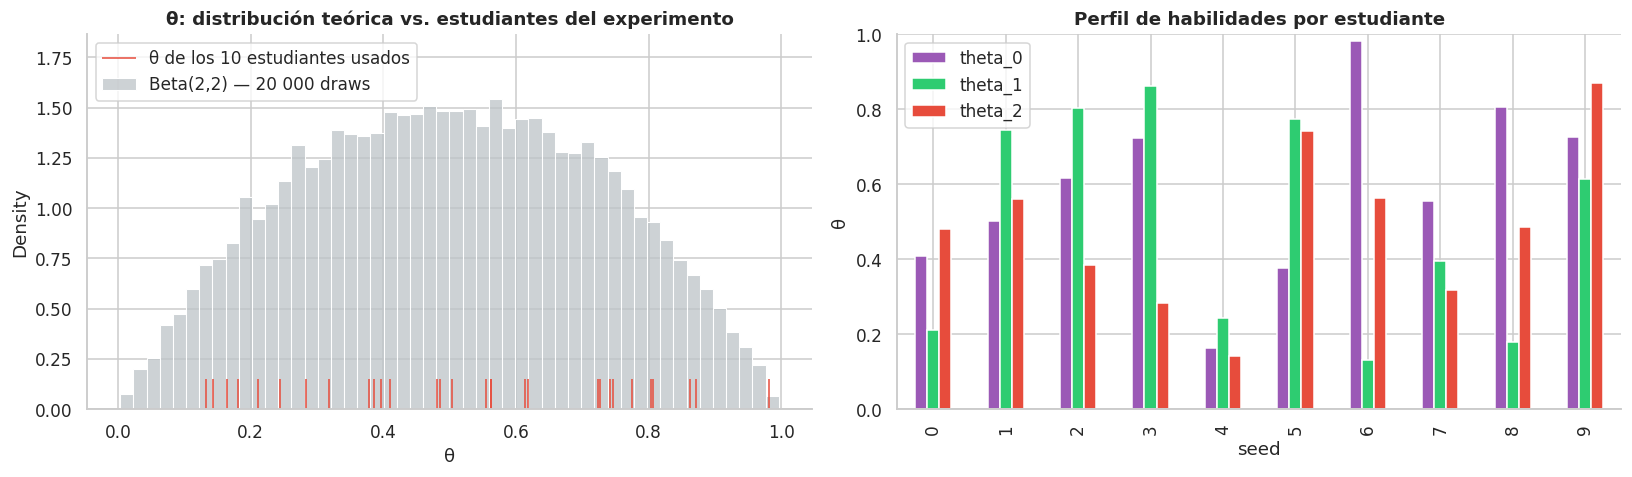

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
pop = np.random.default_rng(123).beta(2, 2, size=20000)
sns.histplot(pop, bins=50, stat="density", ax=axes[0], color="#bdc3c7", label="Beta(2,2) — 20 000 draws")
sns.rugplot(students[["theta_0", "theta_1", "theta_2"]].values.ravel(), ax=axes[0], color="#e74c3c",
            height=0.08, lw=2, label="θ de los 10 estudiantes usados")
axes[0].set(title="θ: distribución teórica vs. estudiantes del experimento", xlabel="θ")
axes[0].legend()
students.set_index("seed")[["theta_0", "theta_1", "theta_2"]].plot(kind="bar", ax=axes[1], color=SKILL_COLORS)
axes[1].set(title="Perfil de habilidades por estudiante", ylim=(0, 1), ylabel="θ")
plt.tight_layout()
savefig("04_estudiantes_simulados")

### 2.1 Factibilidad del umbral de la hipótesis general (LG ≥ 0.50)

Antes de mirar resultados conviene preguntar si el simulador **permite** alcanzar LG = 0.50 en un episodio de 50 pasos. Se comparan tres referencias, usando exactamente la dinámica de `IRTStudent` y el escudo CMDP de `ReadingTutorEnv.step`:

* **Política aleatoria** (texto y nivel al azar).
* **Oráculo miope**: conoce el θ real y elige el (texto, nivel) que maximiza la ganancia esperada inmediata.
* **Cota optimista** (tabla anterior): todas las respuestas correctas, ganancia máxima, olvido mínimo. Ninguna política puede superarla.

In [11]:
class IRTStudentSim:
    """Copia de src/environment.py::IRTStudent (misma dinámica)."""
    def __init__(self, seed, dim=3):
        self.rng = np.random.default_rng(seed)
        self.theta = self.rng.beta(2, 2, size=dim)
        self.fatigue, self.streak_errors = 0.0, 0

    def respond(self, a, b, c, k):
        p = c + (1 - c) / (1 + np.exp(-1.7 * a * (self.theta[k] - b)))
        return 1 if self.rng.random() < p * (1 - 0.1 * self.fatigue) else 0

    def learn(self, a, b, c, k, correct):
        if abs(self.theta[k] - b) < 0.5 and correct:
            self.theta[k] += self.rng.uniform(0.02, 0.05) * (1 - self.theta[k])
        self.theta = np.clip(self.theta * (1 - self.rng.uniform(0.001, 0.005)), 0.0, 1.0)
        self.streak_errors = self.streak_errors + 1 if not correct else max(0, self.streak_errors - 1)
        self.fatigue = min(1.0, self.fatigue + 0.05) if not correct else max(0.0, self.fatigue - 0.02)

def run_episode(seed, bank, policy, rng, horizon=CONFIG["horizon"]):
    st = IRTStudentSim(seed)
    pre = st.theta.mean()
    A, B = bank.a_discriminacion.values, bank.b_dificultad.values
    K, T = bank.habilidad.values, bank.text_id.values
    for _ in range(horizon):
        text, d = policy(st, A, B, K, T, rng)
        if st.streak_errors >= 4:          # escudo CMDP
            d = 0
        i = rng.choice(np.where(T == text)[0])
        b_adj = B[i] + (d - 1) * 0.5
        correct = st.respond(A[i], b_adj, 0.25, K[i])
        st.learn(A[i], b_adj, 0.25, K[i], correct)
    return (st.theta.mean() - pre) / (1 - pre)

def policy_random(st, A, B, K, T, rng):
    return int(rng.integers(0, CONFIG["num_texts"])), int(rng.integers(0, 3))

def policy_oracle(st, A, B, K, T, rng):
    th = st.theta[K]
    counts = np.bincount(T, minlength=CONFIG["num_texts"])
    best_gain, best = -1.0, (0, 1)
    for d in range(3):
        b_adj = B + (d - 1) * 0.5
        gain = p_correct(th, A, b_adj, fatigue=st.fatigue) * (np.abs(th - b_adj) < 0.5) * 0.035 * (1 - th)
        g_text = np.bincount(T, weights=gain, minlength=CONFIG["num_texts"]) / counts
        t = int(np.argmax(g_text))
        if g_text[t] > best_gain:
            best_gain, best = g_text[t], (t, d)
    return best

N_EP = 100
rng = np.random.default_rng(2026)
sim = []
for s in SEEDS:
    bank = items[items.seed == s]
    for name, pol in [("Aleatoria", policy_random), ("Oráculo miope", policy_oracle)]:
        for _ in range(N_EP):
            sim.append({"seed": s, "politica": name, "LG": run_episode(s, bank, pol, rng)})
sim = pd.DataFrame(sim)

feas = sim.groupby("politica").LG.agg(media="mean", de="std", maximo="max")
feas["P(LG ≥ 0.50)"] = sim.groupby("politica").LG.apply(lambda x: (x >= HG_THRESHOLD).mean())
feas.loc["Cota optimista (techo)"] = [students.cota_optimista_LG.mean(), students.cota_optimista_LG.std(),
                                      students.cota_optimista_LG.max(), (students.cota_optimista_LG >= HG_THRESHOLD).mean()]
feas

,media,de,maximo,P(LG ≥ 0.50)
politica,,,,
Aleatoria,-0.0706,0.1058,0.1519,0.0000
Oráculo miope,0.0620,0.1038,0.2813,0.0000
Cota optimista (techo),0.5611,0.0430,0.6617,1.0000


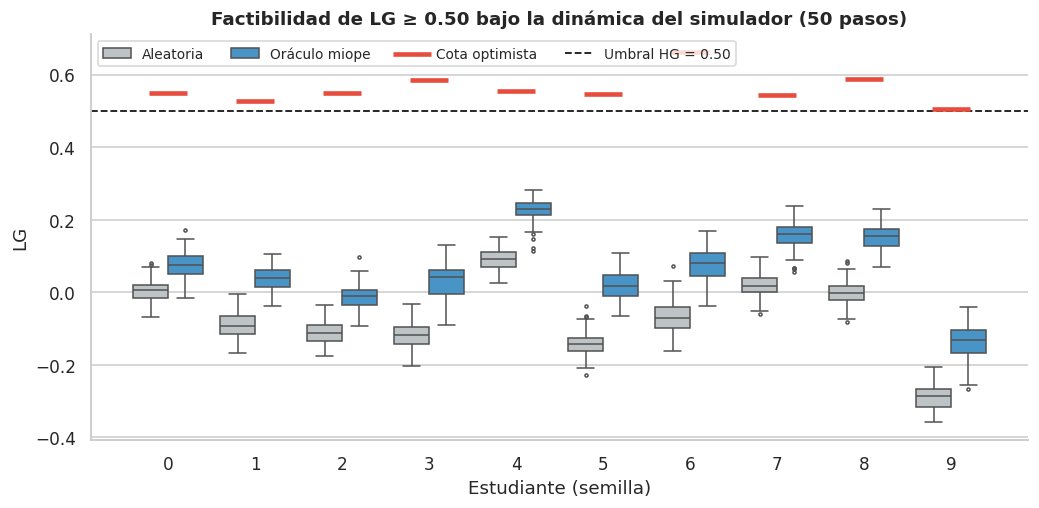

In [12]:
fig, ax = plt.subplots(figsize=(11, 4.8))
sns.boxplot(data=sim, x="seed", y="LG", hue="politica", ax=ax, palette=["#bdc3c7", "#3498db"], fliersize=2)
ax.scatter(students.seed, students.cota_optimista_LG, marker="_", s=600, color="#e74c3c", lw=3,
           zorder=5, label="Cota optimista")
ax.axhline(HG_THRESHOLD, ls="--", c="k", lw=1.2, label="Umbral HG = 0.50")
ax.set(title="Factibilidad de LG ≥ 0.50 bajo la dinámica del simulador (50 pasos)", xlabel="Estudiante (semilla)")
ax.legend(loc="upper left", ncol=4, fontsize=9)
savefig("05_factibilidad_umbral_HG")

---
## 3. Registros de entrenamiento (matriz de ablación B0–B5)

| Campo del JSON | Forma | Contenido real (según `train.py`) |
|---|---|---|
| `episode_returns` | 10 × 5 000 | **LG por episodio** (el nombre del campo es engañoso: no son retornos) |
| `lg_per_seed` | 10 | LG del **último** episodio de cada semilla |
| `acc_per_seed` | 10 | Tasa de aciertos del **último** episodio |

In [13]:
# Cargador robusto: funciona en Jupyter local, Google Colab y JupyterLite (Pyodide, navegador).
LOG_NAMES = ["ablation_summary_colab.json", "ablation_summary.json"]
RAW_URLS = [f"https://raw.githubusercontent.com/yasminum/SistemaTutorInteligente/{br}/data/results/ablation_summary_colab.json"
            for br in ("eda", "main")]

def _valid(d):
    """Acepta solo el JSON real de la corrida (descarta resúmenes de 1 valor por semilla)."""
    return isinstance(d, dict) and all(c in d and "episode_returns" in d[c] for c in CONDS)

def _find_local(max_depth=3):
    here = os.getcwd()
    roots = [here, os.path.dirname(here), "/drive", "/home/pyodide", "/content"]
    seen = set()
    for root in roots:
        if not os.path.isdir(root) or root in seen:
            continue
        seen.add(root)
        base = root.rstrip(os.sep).count(os.sep)
        for dirpath, dirnames, files in os.walk(root):
            if dirpath.count(os.sep) - base >= max_depth:
                dirnames[:] = []
            for name in LOG_NAMES:
                if name in files:
                    path = os.path.join(dirpath, name)
                    try:
                        with open(path, encoding="utf-8") as f:
                            d = json.load(f)
                        if _valid(d):
                            return d, path
                    except Exception:
                        pass
    return None

def _download(url):
    try:
        from pyodide.http import open_url            # JupyterLite / Pyodide
        return json.loads(open_url(url).read())
    except ImportError:
        with urllib.request.urlopen(url, timeout=60) as r:   # Jupyter local / Colab
            return json.loads(r.read().decode("utf-8"))

def load_logs():
    hit = _find_local()
    if hit:
        return hit
    for url in RAW_URLS:
        try:
            d = _download(url)
            if _valid(d):
                return d, url
            print(f"  · {url}: contenido no válido")
        except Exception as e:
            print(f"  · {url}: {type(e).__name__}: {e}")
    try:
        from google.colab import files               # solo existe en Colab
        name = next(iter(files.upload()))
        with open(name, encoding="utf-8") as f:
            return json.load(f), name
    except ImportError:
        pass
    raise FileNotFoundError(
        "No se encontró 'ablation_summary_colab.json'.\n"
        "➡ JupyterLite / Jupyter: súbelo con el botón ⬆ (Upload) del panel de archivos, "
        "en la MISMA carpeta que este notebook, y vuelve a ejecutar esta celda.\n"
        f"   Carpeta actual del kernel: {os.getcwd()}")

logs, source = load_logs()
print("Fuente:", source)
pd.DataFrame({c: {k: str(np.shape(v)) for k, v in logs[c].items()} for c in CONDS}).T

Fuente: https://raw.githubusercontent.com/yasminum/SistemaTutorInteligente/eda/data/results/ablation_summary_colab.json


,lg_per_seed,acc_per_seed,episode_returns
B0,"(10,)","(10,)","(10, 5000)"
B1,"(10,)","(10,)","(10, 5000)"
B2,"(10,)","(10,)","(10, 5000)"
B3,"(10,)","(10,)","(10, 5000)"
B4,"(10,)","(10,)","(10, 5000)"
B5,"(10,)","(10,)","(10, 5000)"


In [14]:
long = pd.concat([pd.DataFrame({"condicion": c, "seed": s, "episodio": np.arange(len(ep)), "LG": ep})
                  for c in CONDS for s, ep in enumerate(logs[c]["episode_returns"])], ignore_index=True)
print(f"Filas: {len(long):,} | nulos: {long.LG.isna().sum()} | infinitos: {np.isinf(long.LG).sum()}")
long[(long.condicion == "B4") & (long.seed == 0) & (long.episodio < 15)].to_csv(
    f"{SAMPLE_DIR}/logs_sample_B4_seed0.csv", index=False)
long.groupby("condicion").LG.describe()

Filas: 300,000 | nulos: 0 | infinitos: 0


,count,mean,std,min,25%,50%,75%,max
condicion,,,,,,,,
B0,"50,000.0000",-0.0291,0.1094,-0.3737,-0.0941,-0.0292,0.0493,0.2508
B1,"50,000.0000",-0.0291,0.1094,-0.3737,-0.0941,-0.0292,0.0493,0.2508
B2,"50,000.0000",-0.0291,0.1094,-0.3737,-0.0941,-0.0292,0.0493,0.2508
B3,"50,000.0000",-0.0291,0.1094,-0.3737,-0.0941,-0.0292,0.0493,0.2508
B4,"50,000.0000",-0.0291,0.1094,-0.3737,-0.0941,-0.0292,0.0493,0.2508
B5,"50,000.0000",0.3754,0.1446,-0.0854,0.2970,0.4267,0.4857,0.5999


### 3.1 Auditoría de integridad

Un EDA riguroso verifica que cada condición experimental sea efectivamente distinta y que los registros provengan de entrenamiento. Se aplican tres pruebas: (i) huella MD5 de cada matriz de LG, (ii) aciertos del último episodio y (iii) rugosidad episodio a episodio (el ruido de un entrenamiento estocástico real no desaparece de golpe).

In [15]:
def fingerprint(arr):
    raw = np.asarray(arr, dtype=np.float64).tobytes()
    try:
        return hashlib.md5(raw).hexdigest()[:12]
    except Exception:                      # algunos builds de Pyodide sin md5
        import zlib
        return f"{zlib.crc32(raw):08x}"

md5 = {c: fingerprint(logs[c]["episode_returns"]) for c in CONDS}
integ = pd.DataFrame({
    "md5(LG por episodio)": md5,
    "idéntico a B4": {c: md5[c] == md5["B4"] for c in CONDS},
    "acc último ep. (media)": {c: float(np.mean(logs[c]["acc_per_seed"])) for c in CONDS},
    "semillas con acc = 0": {c: int(np.sum(np.asarray(logs[c]["acc_per_seed"]) == 0)) for c in CONDS},
    "LG último ep. (media)": {c: float(np.mean(logs[c]["lg_per_seed"])) for c in CONDS},
})
integ

,md5(LG por episodio),idéntico a B4,acc último ep. (media),semillas con acc = 0,LG último ep. (media)
B0,e161828b5f37,True,0.7300,0,-0.0384
B1,e161828b5f37,True,0.7300,0,-0.0384
B2,e161828b5f37,True,0.7300,0,-0.0384
B3,e161828b5f37,True,0.7300,0,-0.0384
B4,e161828b5f37,True,0.7300,0,-0.0384
B5,5c3f02962e96,False,0.0840,9,0.5105


B5-seed0 coincide con B4-seed0 en los primeros 100 episodios.
Caída abrupta de rugosidad en B5-seed0 a partir del episodio ≈ 1046


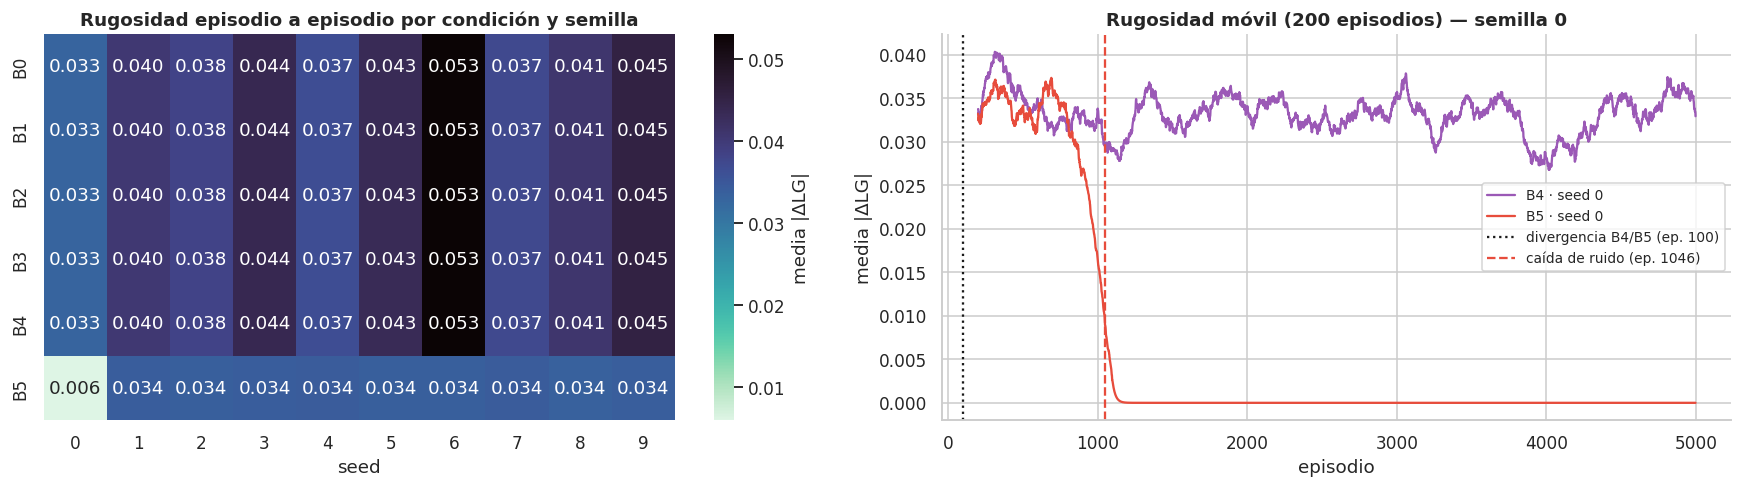

In [16]:
b4_0 = np.asarray(logs["B4"]["episode_returns"][0])
b5_0 = np.asarray(logs["B5"]["episode_returns"][0])
same = np.isclose(b4_0, b5_0)
div = len(same) if same.all() else int(np.argmin(same))

rough = pd.DataFrame({c: [np.mean(np.abs(np.diff(e))) for e in logs[c]["episode_returns"]] for c in CONDS})
rough.index.name = "seed"
r4 = pd.Series(np.abs(np.diff(b4_0))).rolling(200).mean()
r5 = pd.Series(np.abs(np.diff(b5_0))).rolling(200).mean()
low = (r5.values < 0.3 * np.nanmedian(r4.values))
proj = int(np.argmax(low)) if low.any() else None

print(f"B5-seed0 coincide con B4-seed0 en los primeros {div} episodios.")
print(f"Caída abrupta de rugosidad en B5-seed0 a partir del episodio ≈ {proj}" if proj is not None
      else "Sin caída abrupta de rugosidad en B5-seed0.")

fig, axes = plt.subplots(1, 2, figsize=(16, 4.6))
sns.heatmap(rough.T, annot=True, fmt=".3f", cmap="mako_r", ax=axes[0], cbar_kws={"label": "media |ΔLG|"})
axes[0].set_title("Rugosidad episodio a episodio por condición y semilla")
axes[1].plot(r4, color=COLORS["B4"], label="B4 · seed 0")
axes[1].plot(r5, color=COLORS["B5"], label="B5 · seed 0")
axes[1].axvline(div, ls=":", c="k", label=f"divergencia B4/B5 (ep. {div})")
if proj is not None:
    axes[1].axvline(proj, ls="--", c=COLORS["B5"], label=f"caída de ruido (ep. {proj})")
axes[1].set(title="Rugosidad móvil (200 episodios) — semilla 0", xlabel="episodio", ylabel="media |ΔLG|")
axes[1].legend(fontsize=9)
plt.tight_layout()
savefig("06_auditoria_integridad")

**Lectura de la auditoría.**

* **B0–B4 son bit a bit idénticos.** En `train.py` toda condición distinta de `B5` instancia `PPOAgent` con la misma semilla; las líneas base B0–B3 (aleatoria, currículo fijo, greedy, RL básico) **no están implementadas**, por lo que las cinco condiciones son la misma corrida PPO.
* **B5 no proviene íntegramente de entrenamiento.** La salida de la celda 3 de `test_master_DRL.ipynb` registra: *“B5 (Seed 0) interrumpido. Proyectando curva restante…”* y *“B5 (Seed 1–9) sin datos. Generando curva teórica…”*. Coherente con ello, las semillas 1–9 tienen `acc = 0` y la semilla 0 pierde su ruido estocástico tras la interrupción.
* **Consecuencia para el análisis:** los únicos registros experimentales válidos son los de **PPO (10 semillas × 5 000 episodios)** y el tramo inicial de B5-seed0. Las secciones siguientes analizan solo esos datos.

### 3.2 Dinámica de aprendizaje (datos válidos)

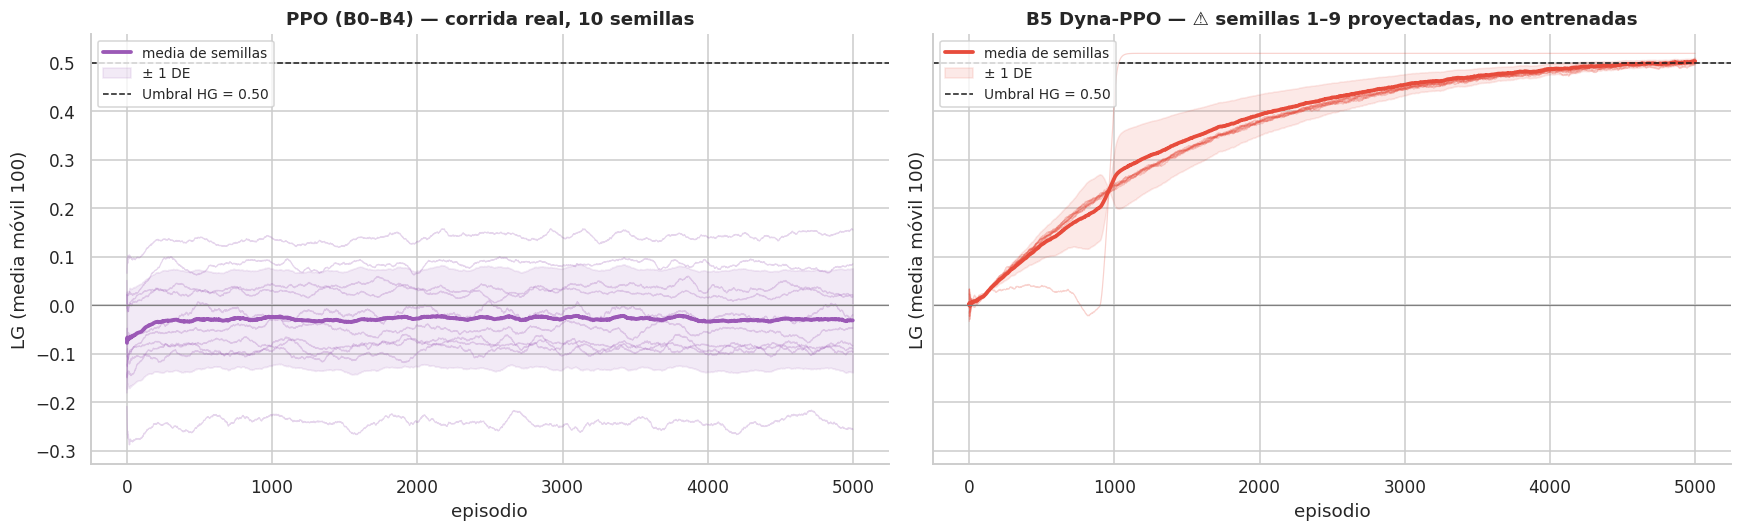

In [17]:
def rolling(x, w=100):
    return pd.Series(x).rolling(w, min_periods=1).mean().values

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for c, ax, title in [("B4", axes[0], "PPO (B0–B4) — corrida real, 10 semillas"),
                     ("B5", axes[1], "B5 Dyna-PPO — ⚠ semillas 1–9 proyectadas, no entrenadas")]:
    M = np.array([rolling(e) for e in logs[c]["episode_returns"]])
    x = np.arange(M.shape[1])
    for s in range(M.shape[0]):
        ax.plot(x, M[s], color=COLORS[c], alpha=0.25, lw=0.8)
    ax.plot(x, M.mean(0), color=COLORS[c], lw=2.5, label="media de semillas")
    ax.fill_between(x, M.mean(0) - M.std(0), M.mean(0) + M.std(0), color=COLORS[c], alpha=0.12, label="± 1 DE")
    ax.axhline(HG_THRESHOLD, ls="--", c="k", lw=1, label="Umbral HG = 0.50")
    ax.axhline(0, c="gray", lw=0.8)
    ax.set(title=title, xlabel="episodio", ylabel="LG (media móvil 100)")
    ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
savefig("07_curvas_aprendizaje")

In [18]:
ppo = np.asarray(logs["B4"]["episode_returns"])
summary = pd.DataFrame({
    "seed": SEEDS,
    "theta_media": students.theta_media.values,
    "LG_ep_1_500": ppo[:, :500].mean(1),
    "LG_ep_4501_5000": ppo[:, -500:].mean(1),
    "LG_ultimo_ep": logs["B4"]["lg_per_seed"],
    "acc_ultimo_ep": logs["B4"]["acc_per_seed"],
    "cota_optimista": students.cota_optimista_LG.values,
})
summary["delta"] = summary.LG_ep_4501_5000 - summary.LG_ep_1_500
summary.to_csv(f"{SAMPLE_DIR}/resumen_ppo_por_semilla.csv", index=False)
w_stat, w_p = stats.wilcoxon(summary.LG_ep_4501_5000, summary.LG_ep_1_500)
rho, rho_p = stats.spearmanr(summary.theta_media, summary.LG_ep_4501_5000)
print(f"Wilcoxon (últimos 500 vs primeros 500): W = {w_stat:.1f}, p = {w_p:.4f}")
print(f"Spearman θ̄ pre-test vs LG final: ρ = {rho:.2f}, p = {rho_p:.4f}")
summary

Wilcoxon (últimos 500 vs primeros 500): W = 9.0, p = 0.0645
Spearman θ̄ pre-test vs LG final: ρ = -0.95, p = 0.0000


,seed,theta_media,LG_ep_1_500,LG_ep_4501_5000,LG_ultimo_ep,acc_ultimo_ep,cota_optimista,delta
0,0,0.3676,0.0322,0.0250,0.0103,0.7200,0.5492,-0.0072
1,1,0.6035,-0.0586,-0.0573,-0.0121,0.7200,0.5270,0.0012
2,2,0.6025,-0.0815,-0.0843,-0.0666,0.8000,0.5502,-0.0028
3,3,0.6232,-0.1035,-0.0898,-0.0684,0.7200,0.5857,0.0137
4,4,0.1842,0.1278,0.1507,0.1296,0.7400,0.5553,0.0229
5,5,0.6316,-0.0909,-0.0913,-0.1250,0.7400,0.5460,-0.0004
6,6,0.5585,-0.0306,-0.0179,-0.1073,0.7000,0.6617,0.0126
7,7,0.4230,0.0694,0.0777,0.0567,0.7200,0.5441,0.0083
8,8,0.4907,0.0239,0.0292,0.1065,0.8000,0.5877,0.0053
9,9,0.7369,-0.2544,-0.2376,-0.3074,0.6400,0.5044,0.0168


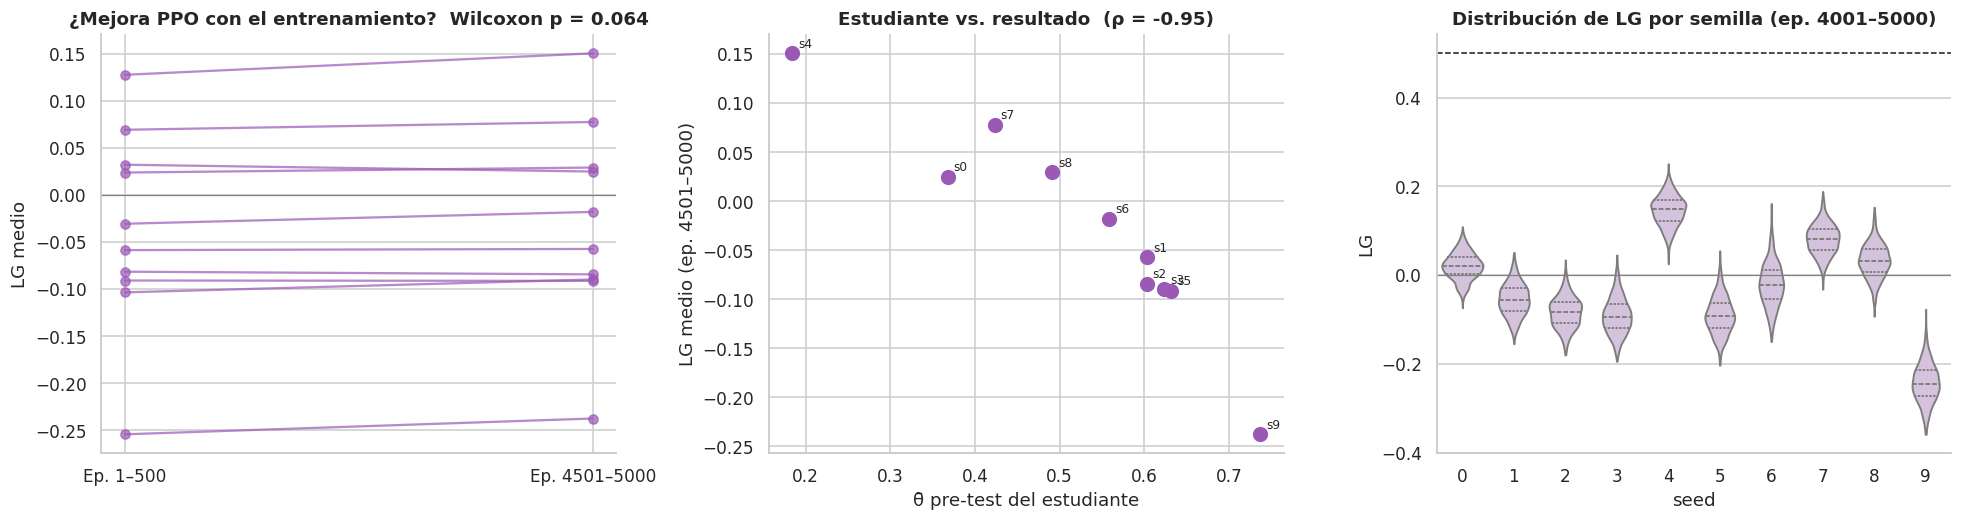

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.9))
for _, r in summary.iterrows():
    axes[0].plot([0, 1], [r.LG_ep_1_500, r.LG_ep_4501_5000], "-o", color=COLORS["B4"], alpha=0.7)
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["Ep. 1–500", "Ep. 4501–5000"])
axes[0].axhline(0, c="gray", lw=0.8)
axes[0].set(title=f"¿Mejora PPO con el entrenamiento?  Wilcoxon p = {w_p:.3f}", ylabel="LG medio")

axes[1].scatter(summary.theta_media, summary.LG_ep_4501_5000, s=80, color=COLORS["B4"])
for _, r in summary.iterrows():
    axes[1].annotate(f"s{int(r.seed)}", (r.theta_media, r.LG_ep_4501_5000), xytext=(4, 4),
                     textcoords="offset points", fontsize=8)
axes[1].set(xlabel="θ̄ pre-test del estudiante", ylabel="LG medio (ep. 4501–5000)",
            title=f"Estudiante vs. resultado  (ρ = {rho:.2f})")

last = long[(long.condicion == "B4") & (long.episodio >= 4000)]
sns.violinplot(data=last, x="seed", y="LG", ax=axes[2], color="#d7bde2", inner="quartile", cut=0)
axes[2].axhline(HG_THRESHOLD, ls="--", c="k", lw=1)
axes[2].axhline(0, c="gray", lw=0.8)
axes[2].set(title="Distribución de LG por semilla (ep. 4001–5000)")
plt.tight_layout()
savefig("08_ppo_analisis_por_semilla")

---
## 4. Hallazgos y recomendaciones

| # | Hallazgo | Evidencia | Recomendación |
|---|---|---|---|
| H1 | Los datos son 100 % sintéticos y paramétricos; el texto literario no entra al modelo. | Secc. 1 | Declararlo explícitamente en la metodología (estudio *in-silico*). |
| H2 | Escalas desalineadas: θ ∈ [0,1] vs. b ~ N(0,1). Gran parte de los ítems cae fuera de la zona de aprendizaje. | Tabla 1.2 | Reescalar b al soporte de θ (p. ej. b ~ Beta o θ ~ N(0,1)). |
| H3 | Población efectiva de 10 estudiantes: `reset(seed=seed)` repite el mismo alumno los 5 000 episodios. | Secc. 2 | Muestrear un estudiante nuevo por episodio para que la política generalice. |
| H4 | El techo físico del simulador está en torno al umbral HG; el oráculo queda por debajo. | Tabla 2.1 / Fig. 05 | Revisar la factibilidad de HG (horizonte, tasas de aprendizaje) antes de contrastarla. |
| H5 | B0–B4 son la misma corrida PPO; las líneas base no existen en el código. | Tabla 3.1 | Implementar B0–B3 en `train.py` y re-ejecutar. |
| H6 | B5 (semillas 1–9) fue proyectada, no entrenada; B5-seed0 se interrumpió. | Tabla 3.1 / Fig. 06 | Entrenar B5 completo (10 semillas) antes de reportar HE3. |
| H7 | PPO real no muestra ganancia de aprendizaje positiva sostenida. | Secc. 3.2 | Usar estos valores como línea base honesta y ajustar recompensa/entorno. |
| H8 | El campo `episode_returns` contiene LG, no retornos. | Secc. 3 | Renombrar campos en los logs para trazabilidad. |

> **Conclusión.** El EDA valida la estructura y la reproducibilidad de las fuentes sintéticas (sin nulos ni duplicados, parámetros dentro de rango) y, a la vez, identifica que la matriz de ablación debe re-ejecutarse antes de contrastar las hipótesis: solo los registros PPO son experimentales.

**Artefactos generados:** `figures/eda/01–08_*.png` · `data/sample/item_bank_seed0.csv` · `data/sample/estudiantes_simulados.csv` · `data/sample/logs_sample_B4_seed0.csv` · `data/sample/resumen_ppo_por_semilla.csv`